# Hospital Patient Analytics
**Portfolio Project — Full Stack Healthcare Analytics**

Analyzing 27,891 encounters across 973 patients from a real hospital dataset stored in MySQL.

## Objectives
1. Admissions & readmissions trends over time
2. Average length of stay (LOS)
3. Average cost per visit & insurance coverage analysis
4. Procedure cost analysis
5. Predictive models: readmission risk & high-cost patients

---

## Section 0 — Environment Setup & Database Connection

In [58]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')

# Load .env from parent directory
load_dotenv(Path('..') / '.env')

DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '3306')
DB_USER = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD', '')
DB_NAME = os.getenv('DB_NAME', 'hospital_db')

engine = create_engine(
    f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
    pool_pre_ping=True
)

# Test connection
with engine.connect() as conn:
    result = conn.execute(text('SELECT COUNT(*) FROM encounters')).fetchone()
    print(f'Connected to {DB_NAME}. Total encounters: {result[0]:,}')

# Output directories
PROCESSED_DIR = Path('..') / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#ec4899']
sns.set_palette(PALETTE)
print('Setup complete.')

Connected to hospital_db. Total encounters: 27,891
Setup complete.


---
## Section 1 — Data Loading & Cleaning

In [59]:
# ── 1.1  Load master encounters dataframe ──────────────────────────────────
ENCOUNTERS_SQL = """
SELECT
    e.Id            AS encounter_id,
    e.START         AS admission_date,
    e.STOP          AS discharge_date,
    e.PATIENT       AS patient_id,
    e.PAYER         AS payer_id,
    e.ENCOUNTERCLASS AS encounter_class,
    e.CODE          AS encounter_code,
    e.DESCRIPTION   AS encounter_description,
    e.BASE_ENCOUNTER_COST AS base_cost,
    e.TOTAL_CLAIM_COST    AS total_cost,
    e.PAYER_COVERAGE      AS payer_coverage,
    e.REASONCODE          AS reason_code,
    e.REASONDESCRIPTION   AS reason_description,
    py.NAME         AS payer_name,
    p.BIRTHDATE     AS birthdate,
    p.DEATHDATE     AS deathdate,
    p.GENDER        AS gender,
    p.RACE          AS race,
    p.ETHNICITY     AS ethnicity,
    p.MARITAL       AS marital_status
FROM encounters e
JOIN patients p  ON e.PATIENT = p.Id
JOIN payers   py ON e.PAYER   = py.Id
"""

df = pd.read_sql(ENCOUNTERS_SQL, engine, parse_dates=['admission_date', 'discharge_date', 'birthdate', 'deathdate'])
print(f'Loaded {len(df):,} encounters | {df["patient_id"].nunique():,} unique patients')
df.head(3)

Loaded 27,872 encounters | 973 unique patients


,encounter_id,admission_date,discharge_date,patient_id,payer_id,encounter_class,encounter_code,encounter_description,base_cost,total_cost,payer_coverage,reason_code,reason_description,payer_name,birthdate,deathdate,gender,race,ethnicity,marital_status
0,0002c38a-54e9-0788-930a-90900dce3612,2011-08-07 09:46:50,2011-08-07 10:01:50,5e129b38-3d63-3692-2a53-c2b56f9d8af0,6e2f1a2d-27bd-3701-8d08-dae202c58632,ambulatory,185349003,Encounter for check-up,85.55,10224.23,6936.92,None,None,Blue Cross Blue Shield,1961-08-06,NaT,F,white,hispanic,M
1,00059b24-6473-ca4a-8795-7373d4ddc7e0,2021-07-15 08:58:01,2021-07-15 09:13:01,45b87421-394d-6654-4d81-6cb5b165e455,6e2f1a2d-27bd-3701-8d08-dae202c58632,outpatient,33879002,Administration of vaccine to produce active im...,142.58,278.58,152.69,None,None,Blue Cross Blue Shield,1956-07-05,NaT,F,black,nonhispanic,S
2,00091c5b-f3a1-ee7b-88cc-850c746f8f58,2013-07-29 01:06:15,2013-07-29 01:21:15,1712d26d-822d-1e3a-2267-0a9dba31d7c8,b1c428d6-4f07-31e0-90f0-68ffa6ff8c76,outpatient,185349003,Encounter for check up (procedure),85.55,85.55,0.00,None,None,NO_INSURANCE,1929-06-30,NaT,F,white,nonhispanic,M


In [60]:
# ── 1.2  Load procedures dataframe ─────────────────────────────────────────
PROCEDURES_SQL = """
SELECT
    pr.PATIENT    AS patient_id,
    pr.ENCOUNTER  AS encounter_id,
    pr.CODE       AS procedure_code,
    pr.DESCRIPTION AS procedure_name,
    pr.BASE_COST  AS procedure_cost,
    pr.REASONDESCRIPTION AS procedure_reason,
    pr.START      AS procedure_start,
    pr.STOP       AS procedure_stop
FROM procedures pr
"""
df_proc = pd.read_sql(PROCEDURES_SQL, engine)
print(f'Loaded {len(df_proc):,} procedures | {df_proc["procedure_code"].nunique():,} unique procedure codes')
df_proc.head(3)

Loaded 47,701 procedures | 157 unique procedure codes


,patient_id,encounter_id,procedure_code,procedure_name,procedure_cost,procedure_reason,procedure_start,procedure_stop
0,3de74169-7f67-9304-91d4-757e0f3a14d2,32c84703-2481-49cd-d571-3899d5820253,265764009,Renal dialysis (procedure),903,None,2011-01-02 09:26:36,2011-01-02 12:58:36
1,d9ec2e44-32e9-9148-179a-1653348cc4e2,c98059da-320a-c0a6-fced-c8815f3e3f39,76601001,Intramuscular injection,2477,None,2011-01-03 05:44:39,2011-01-03 06:01:42
2,d856d6e6-4c98-e7a2-129b-44076c63d008,2cfd4ddd-ad13-fe1e-528b-15051cea2ec3,703423002,Combined chemotherapy and radiation therapy (p...,11620,None,2011-01-04 14:49:55,2011-01-04 15:04:55


In [61]:
# ── 1.3  Data quality profile ───────────────────────────────────────────────
def data_profile(frame, label=''):
    profile = pd.DataFrame({
        'dtype':   frame.dtypes,
        'nulls':   frame.isnull().sum(),
        'null_%':  (frame.isnull().mean() * 100).round(2),
        'unique':  frame.nunique(),
        'sample':  frame.iloc[0] if len(frame) else None
    })
    print(f'\n=== {label} ({len(frame):,} rows) ===')
    return profile

display(data_profile(df, 'Encounters (raw)'))


=== Encounters (raw) (27,872 rows) ===


,dtype,nulls,null_%,unique,sample
encounter_id,object,0,0.00,27872,0002c38a-54e9-0788-930a-90900dce3612
admission_date,datetime64[ns],0,0.00,27522,2011-08-07 09:46:50
discharge_date,datetime64[ns],0,0.00,27746,2011-08-07 10:01:50
patient_id,object,0,0.00,973,5e129b38-3d63-3692-2a53-c2b56f9d8af0
payer_id,object,0,0.00,10,6e2f1a2d-27bd-3701-8d08-dae202c58632
encounter_class,object,0,0.00,6,ambulatory
encounter_code,object,0,0.00,45,185349003
encounter_description,object,0,0.00,53,Encounter for check-up
base_cost,float64,0,0.00,5,85.55
total_cost,float64,0,0.00,13520,10224.23


In [62]:
# ── 1.4  Cleaning ───────────────────────────────────────────────────────────
raw_len = len(df)

# Drop exact duplicates
df = df.drop_duplicates(subset='encounter_id')

# Drop rows where discharge is before admission (data integrity issue)
invalid_dates = df['discharge_date'] < df['admission_date']
df = df[~invalid_dates].copy()

# Compute age at admission
df['age_at_admission'] = ((df['admission_date'] - df['birthdate']).dt.days / 365.25).round(1)
df['age_at_admission'] = df['age_at_admission'].clip(0, 110)

# Deceased flag
df['is_deceased'] = df['deathdate'].notna()

# Standardize encounter_class and payer_name
df['encounter_class'] = df['encounter_class'].str.strip().str.lower()
df['payer_name'] = df['payer_name'].str.strip()

# Insurance covered flag (NO_INSURANCE = not covered)
df['insurance_covered'] = df['payer_name'] != 'NO_INSURANCE'

# Cap cost outliers per encounter_class using 1.5x IQR fencing
def cap_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

df['cost_capped'] = df.groupby('encounter_class')['total_cost'].transform(cap_iqr)

# Impute remaining null costs with encounter_class median
df['cost_capped'] = df['cost_capped'].fillna(df.groupby('encounter_class')['cost_capped'].transform('median'))

print(f'Rows removed during cleaning: {raw_len - len(df):,}')
print(f'Clean dataset: {len(df):,} encounters | {df["patient_id"].nunique():,} patients')
print(f'Null costs remaining: {df["cost_capped"].isnull().sum()}')
print(f'Invalid date rows removed: {invalid_dates.sum()}')

Rows removed during cleaning: 0
Clean dataset: 27,872 encounters | 973 patients
Null costs remaining: 0
Invalid date rows removed: 0


---
## Section 2 — Feature Engineering

In [63]:
# ── 2.1  Time-based features ────────────────────────────────────────────────
df['los_hours'] = (df['discharge_date'] - df['admission_date']).dt.total_seconds() / 3600
df['los_days']  = df['los_hours'] / 24
df['is_inpatient'] = df['encounter_class'] == 'inpatient'

df['admission_year']    = df['admission_date'].dt.year
df['admission_month']   = df['admission_date'].dt.month
df['admission_quarter'] = df['admission_date'].dt.quarter
df['admission_week']    = df['admission_date'].dt.isocalendar().week.astype(int)
df['admission_dow']     = df['admission_date'].dt.day_name()
df['admission_yearmon'] = df['admission_date'].dt.to_period('M').astype(str)

# ── 2.2  Cost features ──────────────────────────────────────────────────────
df['cost_per_day']  = df['cost_capped'] / df['los_days'].clip(lower=1)
df['out_of_pocket'] = (df['total_cost'] - df['payer_coverage']).clip(lower=0)
df['coverage_ratio'] = (df['payer_coverage'] / df['total_cost'].replace(0, np.nan)).clip(0, 1).fillna(0)

# High-cost flag: top 20% within encounter_class
df['high_cost_flag'] = df.groupby('encounter_class')['cost_capped'].transform(
    lambda x: x >= x.quantile(0.80)
)

# ── 2.3  Readmission within 30 days ─────────────────────────────────────────
df_sorted = df.sort_values(['patient_id', 'admission_date']).copy()
df_sorted['prev_discharge'] = df_sorted.groupby('patient_id')['discharge_date'].shift(1)
df_sorted['days_since_discharge'] = (
    df_sorted['admission_date'] - df_sorted['prev_discharge']
).dt.days
df_sorted['readmission_30d'] = df_sorted['days_since_discharge'].between(1, 30, inclusive='both')
df = df_sorted.copy()

# ── 2.4  Patient-level aggregates ───────────────────────────────────────────
patient_stats = df.groupby('patient_id').agg(
    total_encounters=('encounter_id', 'count'),
    readmission_count=('readmission_30d', 'sum'),
    avg_cost=('cost_capped', 'mean'),
    first_encounter=('admission_date', 'min'),
    last_encounter=('admission_date', 'max')
).reset_index()
df = df.merge(patient_stats, on='patient_id', suffixes=('', '_p'))

# ── 2.5  Age group ──────────────────────────────────────────────────────────
df['age_group'] = pd.cut(
    df['age_at_admission'],
    bins=[0, 17, 35, 55, 70, 110],
    labels=['Pediatric', 'Young Adult', 'Middle Age', 'Senior', 'Elderly'],
    right=True
)

print(f'Feature engineering complete. DataFrame shape: {df.shape}')
print(f'Overall 30-day readmission rate: {df["readmission_30d"].mean():.1%}')
print(f'Insurance coverage rate: {df["insurance_covered"].mean():.1%}')
df[['los_hours', 'los_days', 'cost_per_day', 'out_of_pocket', 'coverage_ratio']].describe().round(2)

Feature engineering complete. DataFrame shape: (27872, 46)
Overall 30-day readmission rate: 54.3%
Insurance coverage rate: 68.4%


,los_hours,los_days,cost_per_day,out_of_pocket,coverage_ratio
count,27872.00,27872.00,27872.00,27872.00,27872.00
mean,7.27,0.30,1777.60,2526.12,0.32
std,398.46,16.60,4161.27,7663.38,0.34
min,0.25,0.01,0.00,0.00,0.00
25%,0.25,0.01,142.58,85.55,0.00
50%,0.25,0.01,278.58,172.52,0.28
75%,0.86,0.04,1256.56,1005.25,0.66
max,44930.00,1872.08,34759.70,641882.70,0.95


---
## Section 3 — Exploratory Data Analysis

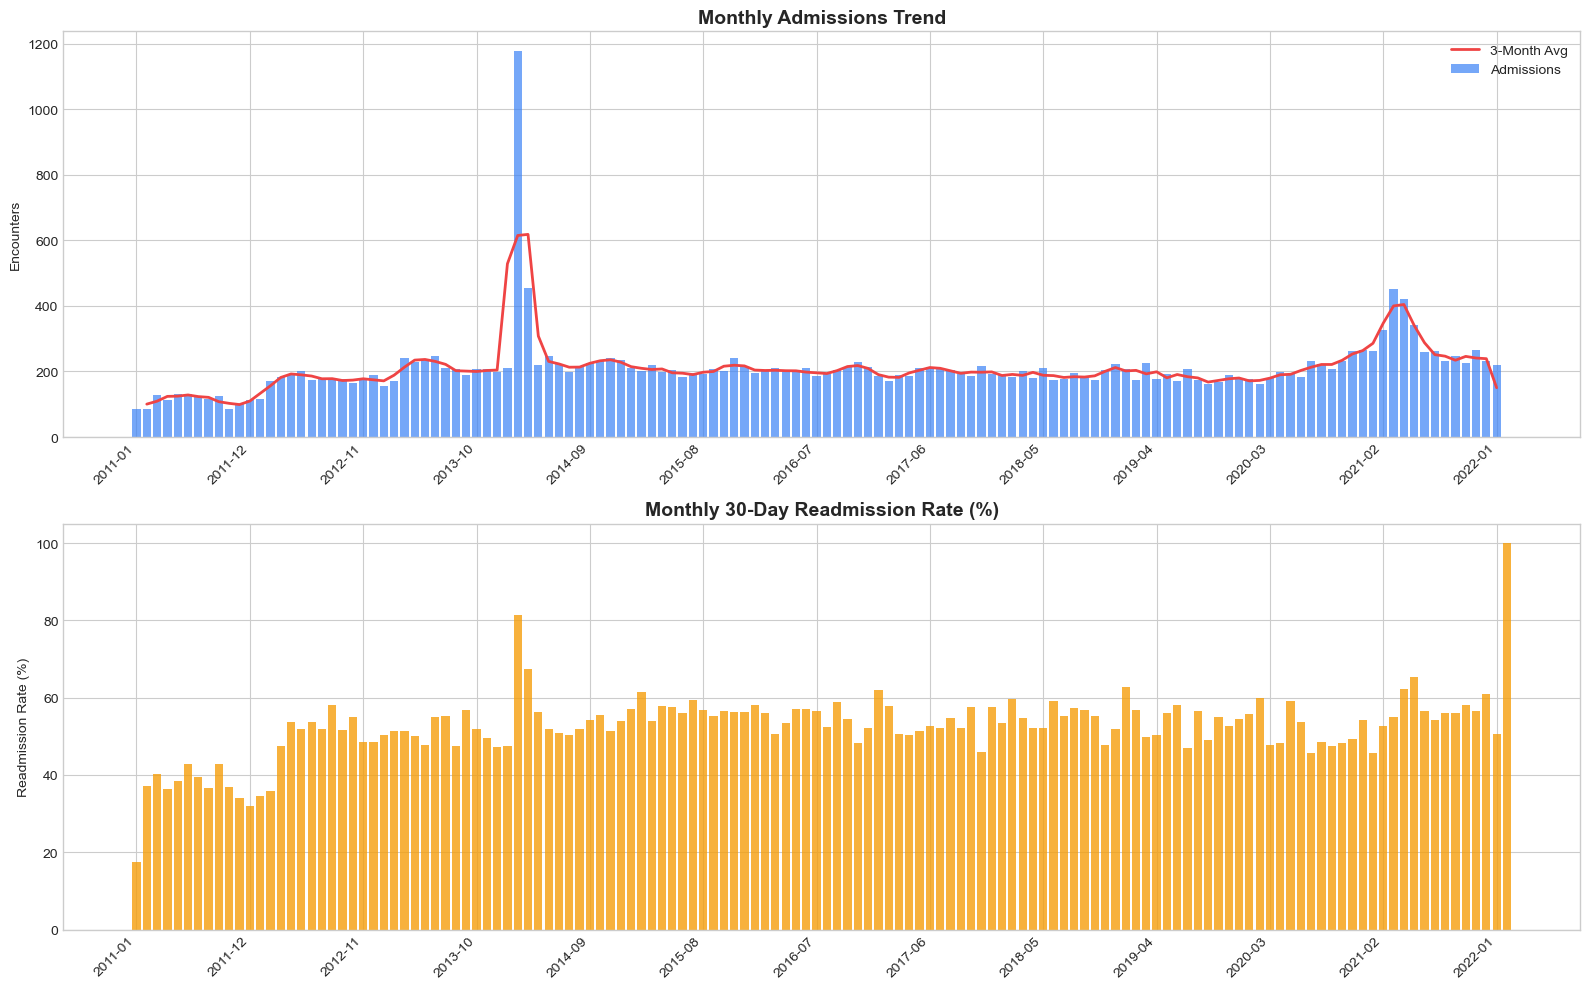

Total admissions: 27,872 | Peak month: 2014-02


In [64]:
# ── 3.1  Admissions Trend ───────────────────────────────────────────────────
monthly = df.groupby('admission_yearmon').agg(
    admissions=('encounter_id', 'count'),
    readmissions=('readmission_30d', 'sum')
).reset_index()
monthly['readmission_rate'] = monthly['readmissions'] / monthly['admissions']
monthly['rolling_avg'] = monthly['admissions'].rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
ax.bar(monthly['admission_yearmon'], monthly['admissions'], color='#3b82f6', alpha=0.7, label='Admissions')
ax.plot(monthly['admission_yearmon'], monthly['rolling_avg'], color='#ef4444', lw=2, label='3-Month Avg')
ax.set_title('Monthly Admissions Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Encounters')
ax.legend()
tick_step = max(1, len(monthly) // 12)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels(monthly['admission_yearmon'].iloc[::tick_step], rotation=45, ha='right')

ax2 = axes[1]
ax2.bar(monthly['admission_yearmon'], monthly['readmission_rate'] * 100, color='#f59e0b', alpha=0.8)
ax2.set_title('Monthly 30-Day Readmission Rate (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Readmission Rate (%)')
ax2.set_xticks(range(0, len(monthly), tick_step))
ax2.set_xticklabels(monthly['admission_yearmon'].iloc[::tick_step], rotation=45, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'admissions_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total admissions: {len(df):,} | Peak month: {monthly.loc[monthly.admissions.idxmax(), "admission_yearmon"]}')

In [65]:
# ── 3.2  Admissions by Encounter Class ─────────────────────────────────────
class_counts = df['encounter_class'].value_counts().reset_index()
class_counts.columns = ['encounter_class', 'count']

fig = px.bar(
    class_counts, x='encounter_class', y='count',
    title='Encounters by Class',
    color='encounter_class',
    color_discrete_sequence=PALETTE,
    text='count'
)
fig.update_layout(showlegend=False, xaxis_title='Encounter Class', yaxis_title='Count')
fig.show()

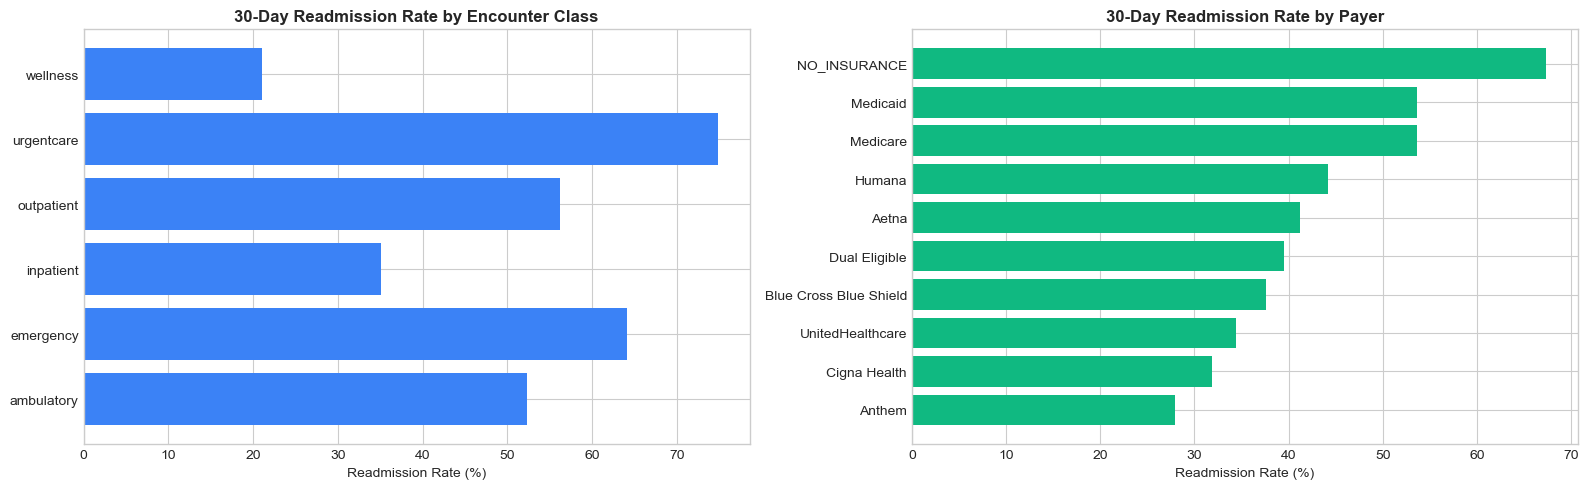

In [66]:
# ── 3.3  Readmission Rate by Encounter Class & Payer ───────────────────────
readm_by_class = df.groupby('encounter_class').agg(
    total=('encounter_id', 'count'),
    readmissions=('readmission_30d', 'sum')
).assign(rate=lambda x: (x.readmissions / x.total * 100).round(2)).reset_index()

readm_by_payer = df.groupby('payer_name').agg(
    total=('encounter_id', 'count'),
    readmissions=('readmission_30d', 'sum')
).assign(rate=lambda x: (x.readmissions / x.total * 100).round(2)).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(readm_by_class['encounter_class'], readm_by_class['rate'], color='#3b82f6')
axes[0].set_title('30-Day Readmission Rate by Encounter Class', fontweight='bold')
axes[0].set_xlabel('Readmission Rate (%)')

readm_by_payer_sorted = readm_by_payer.sort_values('rate')
axes[1].barh(readm_by_payer_sorted['payer_name'], readm_by_payer_sorted['rate'], color='#10b981')
axes[1].set_title('30-Day Readmission Rate by Payer', fontweight='bold')
axes[1].set_xlabel('Readmission Rate (%)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'readmission_rates.png', dpi=150, bbox_inches='tight')
plt.show()

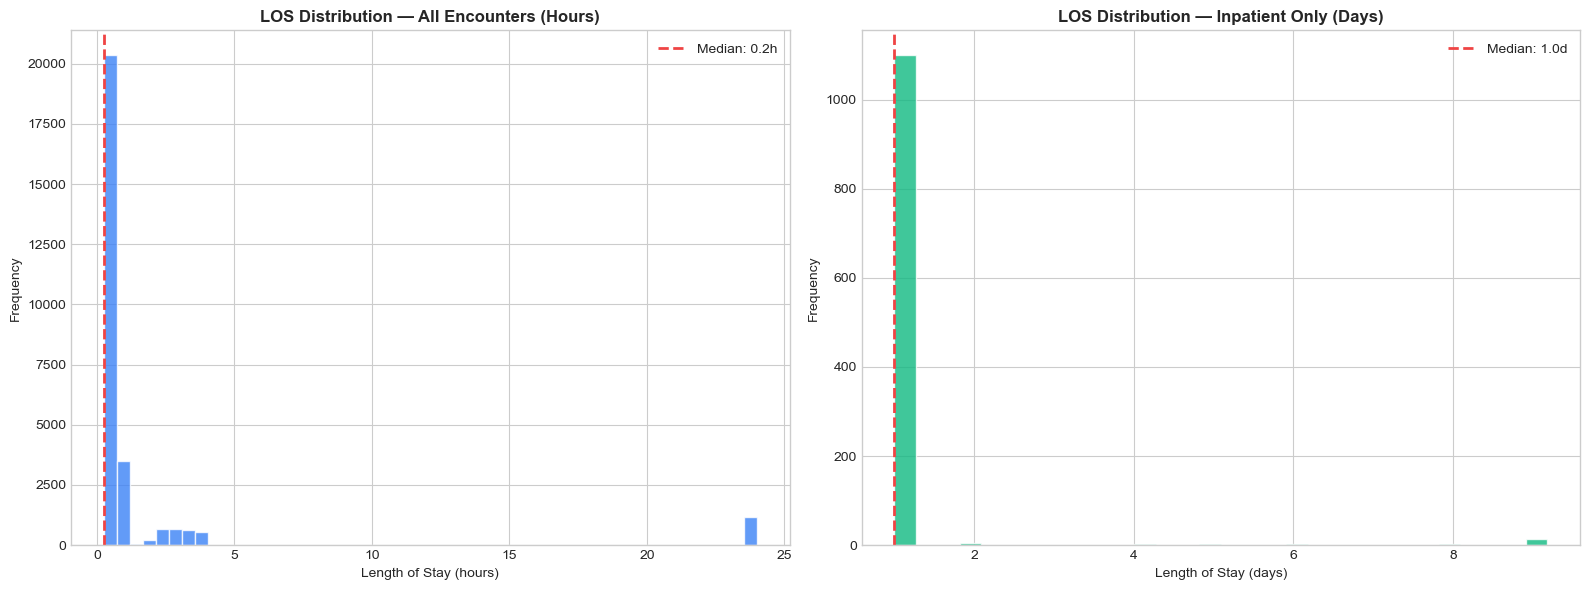


LOS Summary:
                  mean  median    p95
encounter_class                      
ambulatory        9.48    0.25   3.53
emergency         1.54    1.00   1.00
inpatient        36.84   24.00  24.63
outpatient        5.88    0.25   0.32
urgentcare        0.25    0.25   0.25
wellness          0.25    0.25   0.25


In [67]:
# ── 3.4  LOS Analysis ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All encounters: LOS in hours (most are same-day)
los_clip = df['los_hours'].clip(upper=df['los_hours'].quantile(0.99))
axes[0].hist(los_clip, bins=50, color='#3b82f6', alpha=0.8, edgecolor='white')
axes[0].set_title('LOS Distribution — All Encounters (Hours)', fontweight='bold')
axes[0].set_xlabel('Length of Stay (hours)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['los_hours'].median(), color='#ef4444', lw=2, linestyle='--', label=f'Median: {df["los_hours"].median():.1f}h')
axes[0].legend()

# Inpatient only: LOS in days
inpatient = df[df['is_inpatient']]
axes[1].hist(inpatient['los_days'].clip(upper=inpatient['los_days'].quantile(0.99)), bins=30, color='#10b981', alpha=0.8, edgecolor='white')
axes[1].set_title('LOS Distribution — Inpatient Only (Days)', fontweight='bold')
axes[1].set_xlabel('Length of Stay (days)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(inpatient['los_days'].median(), color='#ef4444', lw=2, linestyle='--', label=f'Median: {inpatient["los_days"].median():.1f}d')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'los_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nLOS Summary:')
print(df.groupby('encounter_class')['los_hours'].agg(['mean', 'median', lambda x: x.quantile(0.95)]).round(2).rename(columns={'<lambda_0>': 'p95'}))

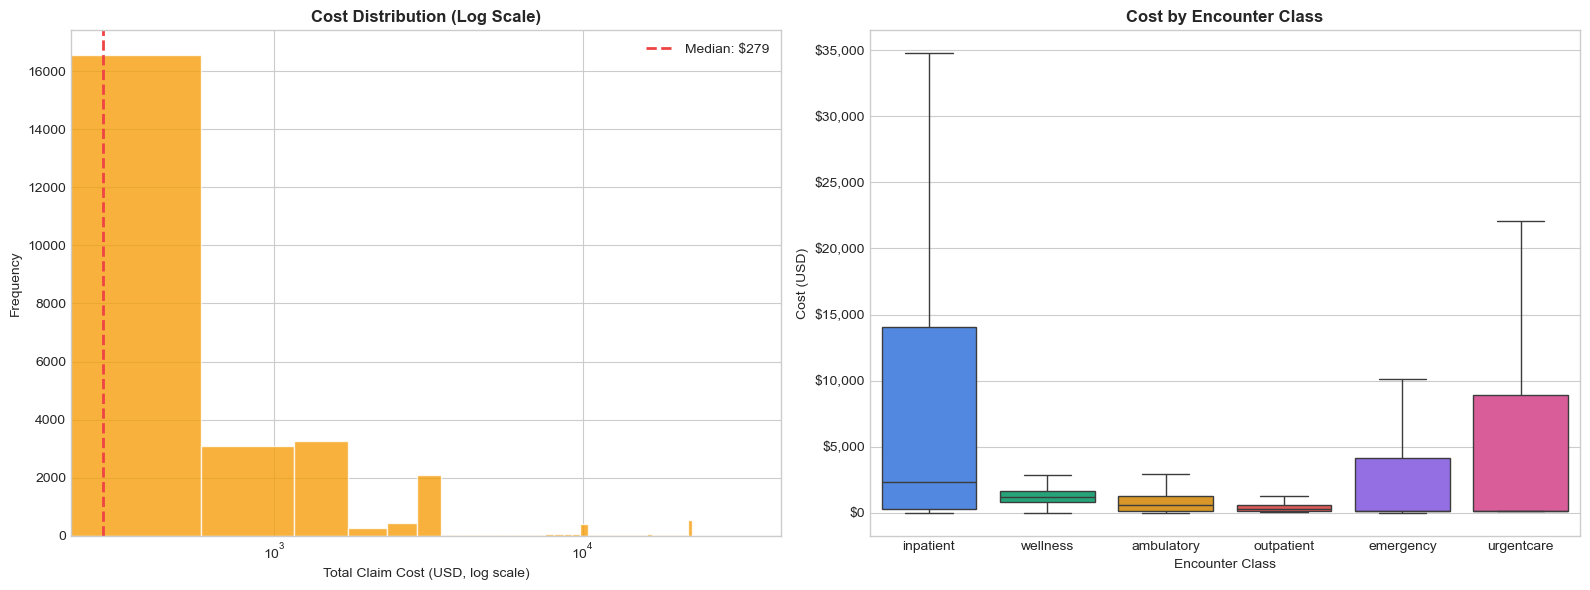


Average cost: $1,796.15 | Median: $278.58


In [68]:
# ── 3.5  Cost Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (log scale)
axes[0].hist(df['cost_capped'].dropna(), bins=60, color='#f59e0b', alpha=0.8, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_title('Cost Distribution (Log Scale)', fontweight='bold')
axes[0].set_xlabel('Total Claim Cost (USD, log scale)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['cost_capped'].median(), color='#ef4444', lw=2, linestyle='--',
                label=f'Median: ${df["cost_capped"].median():,.0f}')
axes[0].legend()

# Box plots by encounter class
enc_order = df.groupby('encounter_class')['cost_capped'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='encounter_class', y='cost_capped', order=enc_order,
            palette=PALETTE, ax=axes[1], showfliers=False)
axes[1].set_title('Cost by Encounter Class', fontweight='bold')
axes[1].set_xlabel('Encounter Class')
axes[1].set_ylabel('Cost (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage cost: ${df['cost_capped'].mean():,.2f} | Median: ${df['cost_capped'].median():,.2f}")

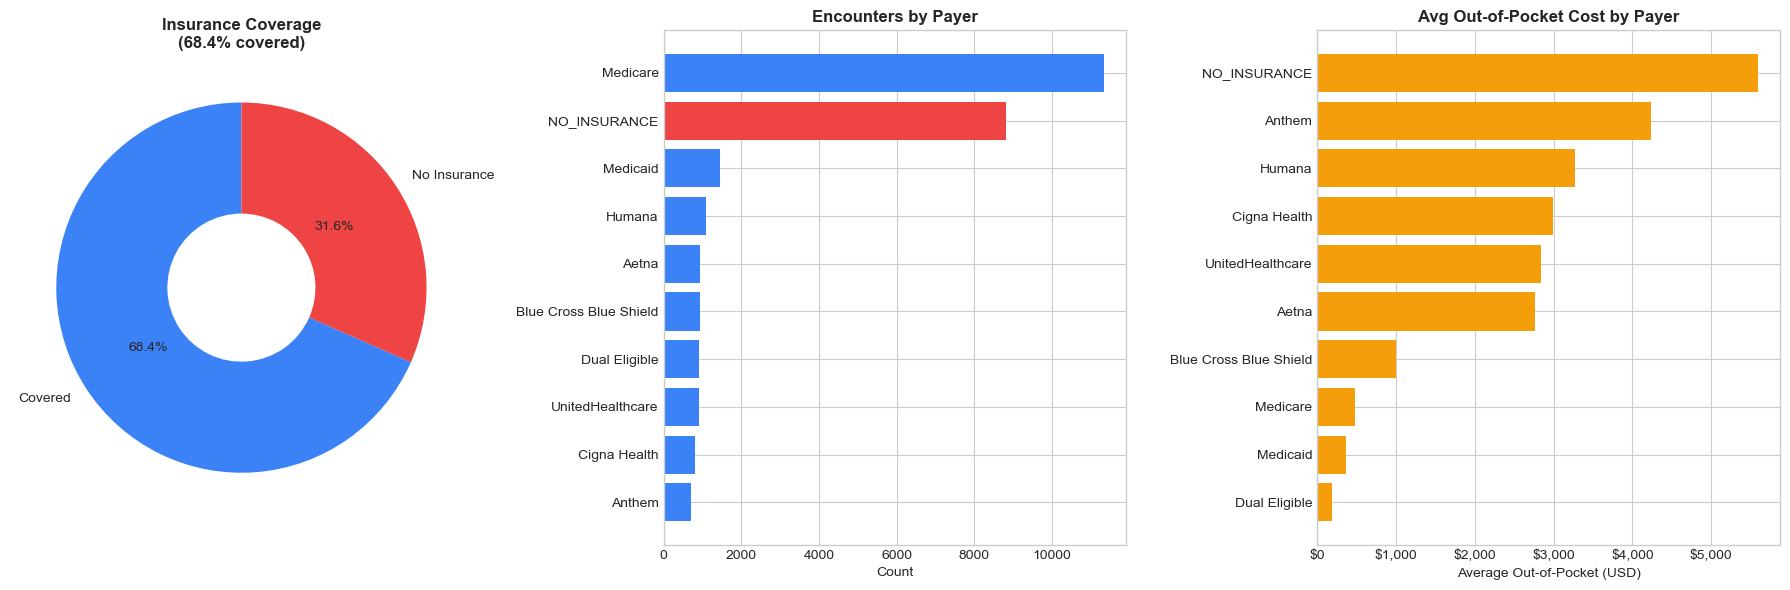

Covered: 19,065 | No insurance: 8,807


In [69]:
# ── 3.6  Insurance Coverage Analysis ───────────────────────────────────────
coverage_counts = df['insurance_covered'].value_counts()
coverage_pct = df['insurance_covered'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Donut chart
axes[0].pie(
    [coverage_counts.get(True, 0), coverage_counts.get(False, 0)],
    labels=['Covered', 'No Insurance'],
    colors=['#3b82f6', '#ef4444'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.6}
)
axes[0].set_title(f'Insurance Coverage\n({coverage_pct:.1f}% covered)', fontweight='bold')

# By payer
payer_vol = df['payer_name'].value_counts().reset_index()
payer_vol.columns = ['payer_name', 'count']
payer_vol_sorted = payer_vol.sort_values('count')
axes[1].barh(payer_vol_sorted['payer_name'], payer_vol_sorted['count'],
             color=['#ef4444' if p == 'NO_INSURANCE' else '#3b82f6' for p in payer_vol_sorted['payer_name']])
axes[1].set_title('Encounters by Payer', fontweight='bold')
axes[1].set_xlabel('Count')

# Avg out-of-pocket by payer
oop_by_payer = df.groupby('payer_name')['out_of_pocket'].mean().sort_values(ascending=True)
axes[2].barh(oop_by_payer.index, oop_by_payer.values, color='#f59e0b')
axes[2].set_title('Avg Out-of-Pocket Cost by Payer', fontweight='bold')
axes[2].set_xlabel('Average Out-of-Pocket (USD)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'insurance_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Covered: {coverage_counts.get(True, 0):,} | No insurance: {coverage_counts.get(False, 0):,}')

---
## Section 3B — Business Questions

Direct answers to the four core business questions driving this analysis.

Q1: ADMISSIONS & READMISSIONS OVER TIME

Total encounters (all time):     27,872
Total unique patients:           973
Total 30-day readmissions:       15,122
Overall 30-day readmission rate: 54.3%

Year-by-year breakdown:
 admission_year  admissions  readmissions  unique_patients  readmission_rate_pct
           2011        1335           491              409                  36.8
           2012        2105          1047              558                  49.7
           2013        2492          1275              569                  51.2
           2014        3884          2449              629                  63.1
           2015        2467          1406              552                  57.0
           2016        2450          1335              551                  54.5
           2017        2359          1263              545                  53.5
           2018        2291          1248              534                  54.5
           2019        2226          1202        

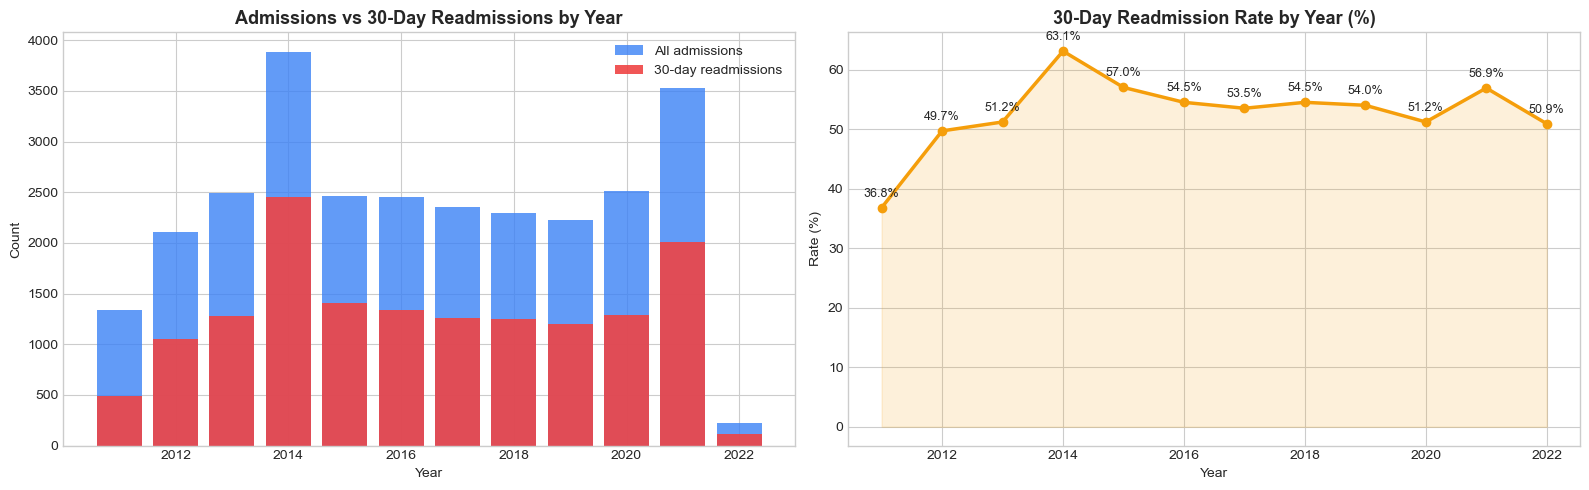


-> Figure saved: q1_admissions_over_time.png


In [70]:
# ── Q1: How many patients have been admitted or readmitted over time? ─────
print('=' * 65)
print('Q1: ADMISSIONS & READMISSIONS OVER TIME')
print('=' * 65)

yearly = df.groupby('admission_year').agg(
    admissions=('encounter_id', 'count'),
    readmissions=('readmission_30d', 'sum'),
    unique_patients=('patient_id', 'nunique')
).reset_index()
yearly['readmission_rate_pct'] = (yearly['readmissions'] / yearly['admissions'] * 100).round(1)

print(f'\nTotal encounters (all time):     {len(df):,}')
print(f'Total unique patients:           {df["patient_id"].nunique():,}')
print(f'Total 30-day readmissions:       {int(df["readmission_30d"].sum()):,}')
print(f'Overall 30-day readmission rate: {df["readmission_30d"].mean()*100:.1f}%')
print(f'\nYear-by-year breakdown:')
print(yearly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(yearly['admission_year'], yearly['admissions'], color='#3b82f6', alpha=0.8, label='All admissions')
axes[0].bar(yearly['admission_year'], yearly['readmissions'], color='#ef4444', alpha=0.9, label='30-day readmissions')
axes[0].set_title('Admissions vs 30-Day Readmissions by Year', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(yearly['admission_year'], yearly['readmission_rate_pct'], color='#f59e0b', marker='o', lw=2.5)
axes[1].fill_between(yearly['admission_year'], yearly['readmission_rate_pct'], alpha=0.15, color='#f59e0b')
axes[1].set_title('30-Day Readmission Rate by Year (%)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Rate (%)')
for _, row in yearly.iterrows():
    axes[1].annotate(
        f"{row['readmission_rate_pct']:.1f}%",
        (row['admission_year'], row['readmission_rate_pct']),
        textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q1_admissions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n-> Figure saved: q1_admissions_over_time.png')


Q2: AVERAGE LENGTH OF STAY

--- All encounter classes ---
  Mean LOS:    7.3 h  (0.30 days)
  Median LOS:  0.2 h  (0.01 days)
  (Most encounters are same-day ambulatory visits, pulling the median down.)

--- Inpatient only (clinically meaningful multi-day stays) ---
  Mean LOS:    1.5 days
  Median LOS:  1.0 days
  95th pctile: 1.0 days
  n encounters: 1,135

--- Average LOS by encounter class ---
                  mean  median  count  mean_days
encounter_class                                 
ambulatory        9.48    0.25  12534       0.40
emergency         1.54    1.00   2321       0.06
inpatient        36.84   24.00   1135       1.54
outpatient        5.88    0.25   6297       0.24
urgentcare        0.25    0.25   3665       0.01
wellness          0.25    0.25   1920       0.01


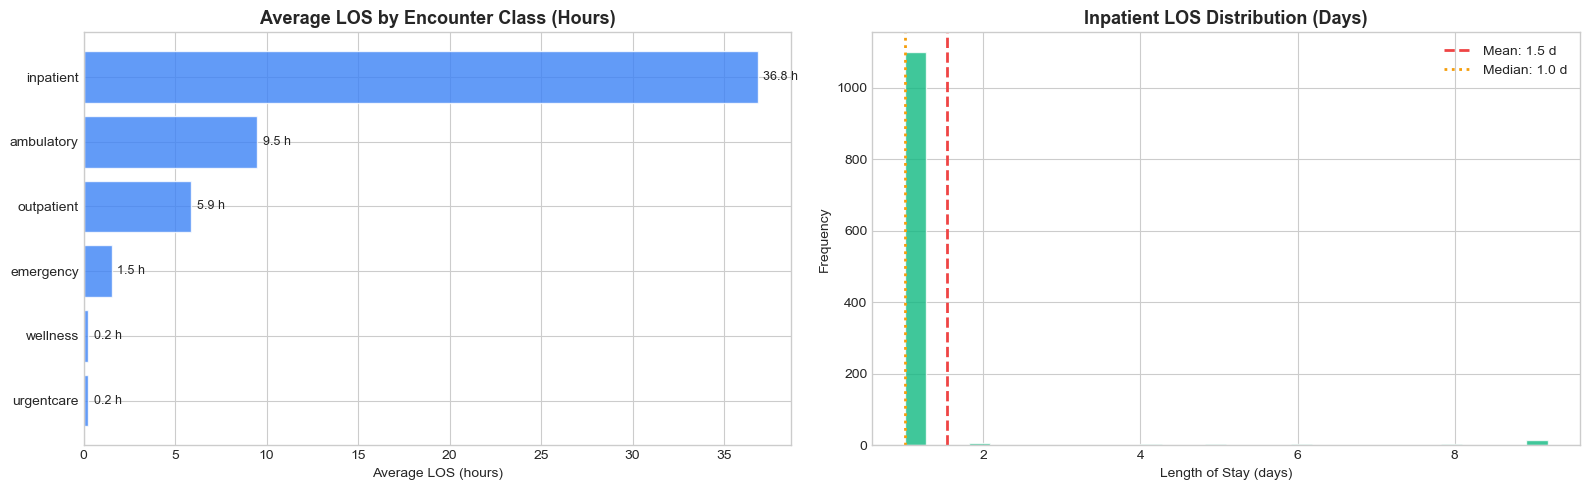


-> Figure saved: q2_avg_los.png


In [71]:
# ── Q2: How long are patients staying in the hospital, on average? ────────
print('=' * 65)
print('Q2: AVERAGE LENGTH OF STAY')
print('=' * 65)

inpatient = df[df['is_inpatient']]

print(f'\n--- All encounter classes ---')
print(f'  Mean LOS:    {df["los_hours"].mean():.1f} h  ({df["los_hours"].mean()/24:.2f} days)')
print(f'  Median LOS:  {df["los_hours"].median():.1f} h  ({df["los_hours"].median()/24:.2f} days)')
print(f'  (Most encounters are same-day ambulatory visits, pulling the median down.)')

print(f'\n--- Inpatient only (clinically meaningful multi-day stays) ---')
print(f'  Mean LOS:    {inpatient["los_days"].mean():.1f} days')
print(f'  Median LOS:  {inpatient["los_days"].median():.1f} days')
print(f'  95th pctile: {inpatient["los_days"].quantile(0.95):.1f} days')
print(f'  n encounters: {len(inpatient):,}')

print(f'\n--- Average LOS by encounter class ---')
los_by_cls = df.groupby('encounter_class')['los_hours'].agg(mean='mean', median='median', count='count').round(2)
los_by_cls['mean_days'] = (los_by_cls['mean'] / 24).round(2)
print(los_by_cls.to_string())

los_summary_df = df.groupby('encounter_class')['los_hours'].mean().sort_values().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].barh(los_summary_df['encounter_class'], los_summary_df['los_hours'],
                    color='#3b82f6', alpha=0.8, edgecolor='white')
axes[0].set_title('Average LOS by Encounter Class (Hours)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Average LOS (hours)')
for bar, val in zip(bars, los_summary_df['los_hours']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f} h', va='center', fontsize=9)

inpatient_los_clip = inpatient['los_days'].clip(upper=inpatient['los_days'].quantile(0.99))
axes[1].hist(inpatient_los_clip, bins=30, color='#10b981', alpha=0.8, edgecolor='white')
axes[1].axvline(inpatient['los_days'].mean(), color='#ef4444', lw=2, linestyle='--',
                label=f'Mean: {inpatient["los_days"].mean():.1f} d')
axes[1].axvline(inpatient['los_days'].median(), color='#f59e0b', lw=2, linestyle=':',
                label=f'Median: {inpatient["los_days"].median():.1f} d')
axes[1].set_title('Inpatient LOS Distribution (Days)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Length of Stay (days)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q2_avg_los.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n-> Figure saved: q2_avg_los.png')


Q3: AVERAGE COST PER VISIT

--- Overall ---
  Mean cost:       $  1,796.15
  Median cost:     $    278.58
  95th percentile: $ 10,159.71
  Total revenue:   $50,062,243

--- Average cost by encounter class ---
                 mean_cost  median_cost  count
encounter_class                               
inpatient          7084.50      2355.59   1135
urgentcare         5213.67       142.58   3665
emergency          2495.44       146.18   2321
wellness           1400.51      1231.93   1920
ambulatory          918.85       573.98  12534
outpatient          462.98       278.58   6297

--- Average cost by payer ---
                        mean_cost  count
payer_name                              
NO_INSURANCE              3150.26   8807
Medicaid                  1629.09   1443
Humana                    1325.57   1084
Medicare                  1172.97  11352
Blue Cross Blue Shield    1119.30    925
Aetna                     1057.24    936
Cigna Health              1041.10    809
UnitedHealthcar

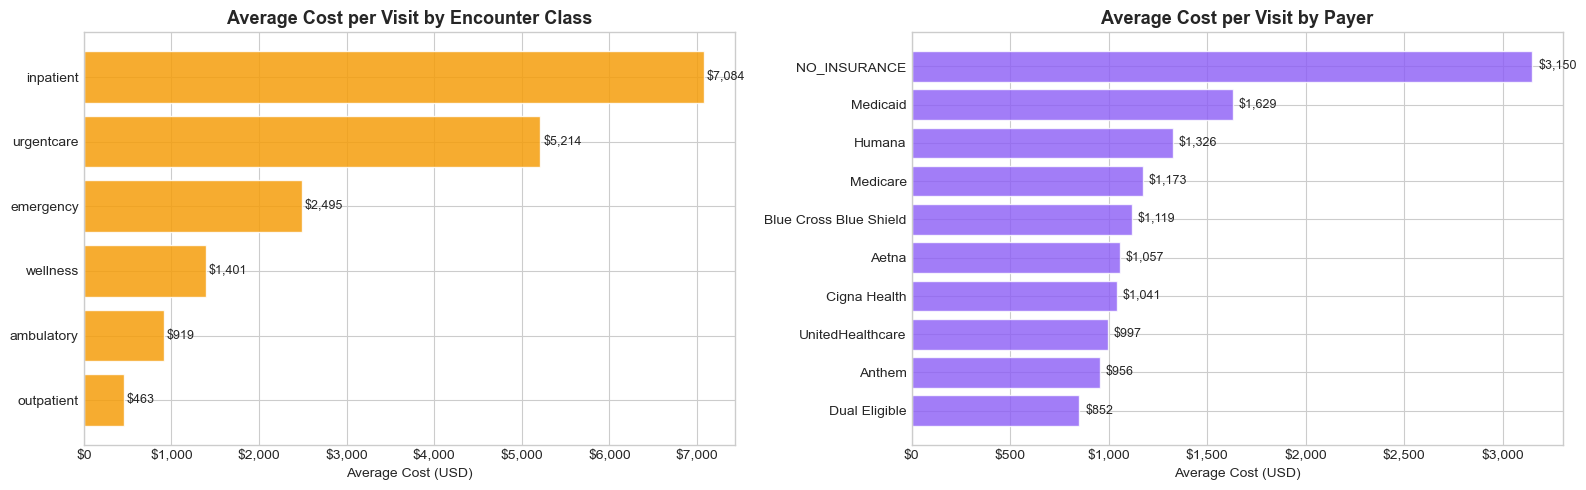


-> Figure saved: q3_avg_cost.png


In [72]:
# ── Q3: What is the average cost per visit? ────────────────────────────────
print('=' * 65)
print('Q3: AVERAGE COST PER VISIT')
print('=' * 65)

print(f'\n--- Overall ---')
print(f'  Mean cost:       ${df["cost_capped"].mean():>10,.2f}')
print(f'  Median cost:     ${df["cost_capped"].median():>10,.2f}')
print(f'  95th percentile: ${df["cost_capped"].quantile(0.95):>10,.2f}')
print(f'  Total revenue:   ${df["cost_capped"].sum():>10,.0f}')

print(f'\n--- Average cost by encounter class ---')
cost_by_cls = df.groupby('encounter_class')['cost_capped'].agg(
    mean_cost='mean', median_cost='median', count='count'
).round(2).sort_values('mean_cost', ascending=False)
print(cost_by_cls.to_string())

print(f'\n--- Average cost by payer ---')
cost_by_payer = df.groupby('payer_name')['cost_capped'].agg(
    mean_cost='mean', count='count'
).round(2).sort_values('mean_cost', ascending=False)
print(cost_by_payer.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cost_cls_df = cost_by_cls.reset_index().sort_values('mean_cost')
bars = axes[0].barh(cost_cls_df['encounter_class'], cost_cls_df['mean_cost'],
                    color='#f59e0b', alpha=0.85, edgecolor='white')
axes[0].set_title('Average Cost per Visit by Encounter Class', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Average Cost (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, cost_cls_df['mean_cost']):
    axes[0].text(val + 30, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

cost_pay_df = cost_by_payer.reset_index().sort_values('mean_cost')
bars2 = axes[1].barh(cost_pay_df['payer_name'], cost_pay_df['mean_cost'],
                     color='#8b5cf6', alpha=0.8, edgecolor='white')
axes[1].set_title('Average Cost per Visit by Payer', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Average Cost (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars2, cost_pay_df['mean_cost']):
    axes[1].text(val + 30, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q3_avg_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n-> Figure saved: q3_avg_cost.png')


Q4: PROCEDURES COVERED BY INSURANCE

--- Overall ---
  Total procedures:  47,701
  Covered:           32,536  (68.2%)
  Not covered:       15,165  (31.8%)

--- Coverage by encounter class ---
                 total_procedures  covered_procedures  pct_covered
encounter_class                                                   
ambulatory                  17818               11728         65.8
emergency                    1440                 983         68.3
inpatient                    3137                1920         61.2
outpatient                  14958               10039         67.1
urgentcare                   1047                 194         18.5
wellness                     9238                7672         83.0

--- Coverage by payer ---
                        total  covered  pct_covered
payer_name                                         
Aetna                    1457     1457        100.0
Anthem                   1203     1203        100.0
Blue Cross Blue Shield   1512     151

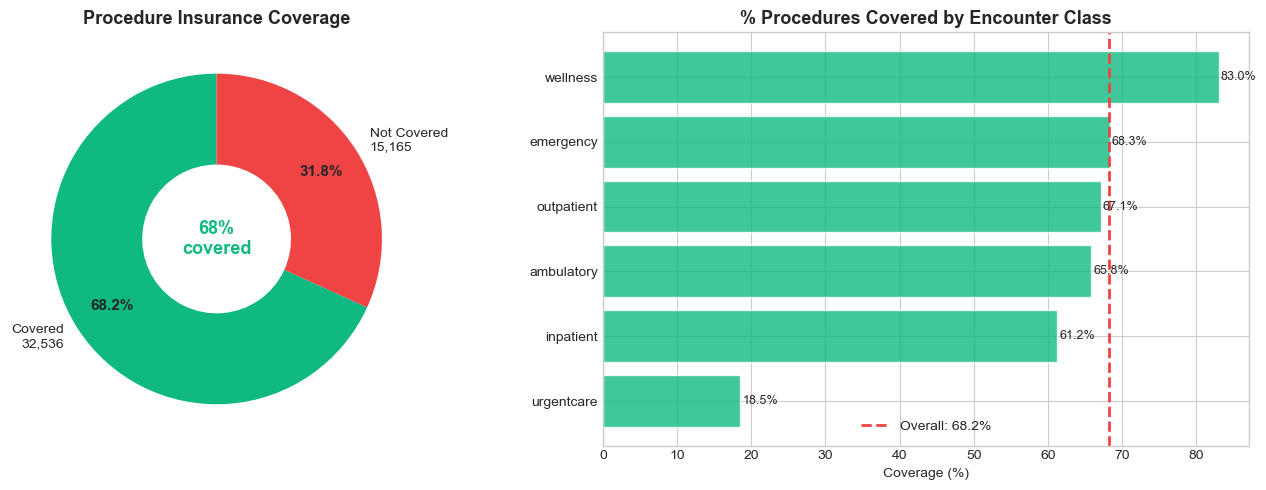


-> Figure saved: q4_procedure_coverage.png


In [73]:
# ── Q4: How many procedures are covered by insurance? ──────────────────────
print('=' * 65)
print('Q4: PROCEDURES COVERED BY INSURANCE')
print('=' * 65)

proc_with_ins = df_proc.merge(
    df[['encounter_id', 'insurance_covered', 'payer_name', 'encounter_class']],
    on='encounter_id', how='left'
)
proc_with_ins['insurance_covered'] = proc_with_ins['insurance_covered'].fillna(False)

total_procs = len(proc_with_ins)
covered     = int(proc_with_ins['insurance_covered'].sum())
not_covered = total_procs - covered

print(f'\n--- Overall ---')
print(f'  Total procedures:  {total_procs:,}')
print(f'  Covered:           {covered:,}  ({covered/total_procs*100:.1f}%)')
print(f'  Not covered:       {not_covered:,}  ({not_covered/total_procs*100:.1f}%)')

print(f'\n--- Coverage by encounter class ---')
proc_by_cls = proc_with_ins.groupby('encounter_class').agg(
    total_procedures=('insurance_covered', 'count'),
    covered_procedures=('insurance_covered', 'sum')
)
proc_by_cls['pct_covered'] = (proc_by_cls['covered_procedures'] / proc_by_cls['total_procedures'] * 100).round(1)
print(proc_by_cls.to_string())

print(f'\n--- Coverage by payer ---')
proc_by_pay = proc_with_ins.groupby('payer_name').agg(
    total=('insurance_covered', 'count'),
    covered=('insurance_covered', 'sum')
)
proc_by_pay['pct_covered'] = (proc_by_pay['covered'] / proc_by_pay['total'] * 100).round(1)
print(proc_by_pay.sort_values('pct_covered', ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wedges, texts, autotexts = axes[0].pie(
    [covered, not_covered],
    labels=[f'Covered\n{covered:,}', f'Not Covered\n{not_covered:,}'],
    colors=['#10b981', '#ef4444'], autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(width=0.55), pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
axes[0].set_title('Procedure Insurance Coverage', fontweight='bold', fontsize=13)
axes[0].text(0, 0, f'{covered/total_procs*100:.0f}%\ncovered',
             ha='center', va='center', fontsize=13, fontweight='bold', color='#10b981')

cls_cov = proc_by_cls.reset_index().sort_values('pct_covered')
bars = axes[1].barh(cls_cov['encounter_class'], cls_cov['pct_covered'],
                    color='#10b981', alpha=0.8, edgecolor='white')
axes[1].axvline(covered/total_procs*100, color='#ef4444', lw=2, linestyle='--',
                label=f'Overall: {covered/total_procs*100:.1f}%')
axes[1].set_title('% Procedures Covered by Encounter Class', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Coverage (%)')
axes[1].legend()
for bar, val in zip(bars, cls_cov['pct_covered']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'q4_procedure_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n-> Figure saved: q4_procedure_coverage.png')


---
## Section 4 — Advanced Insights

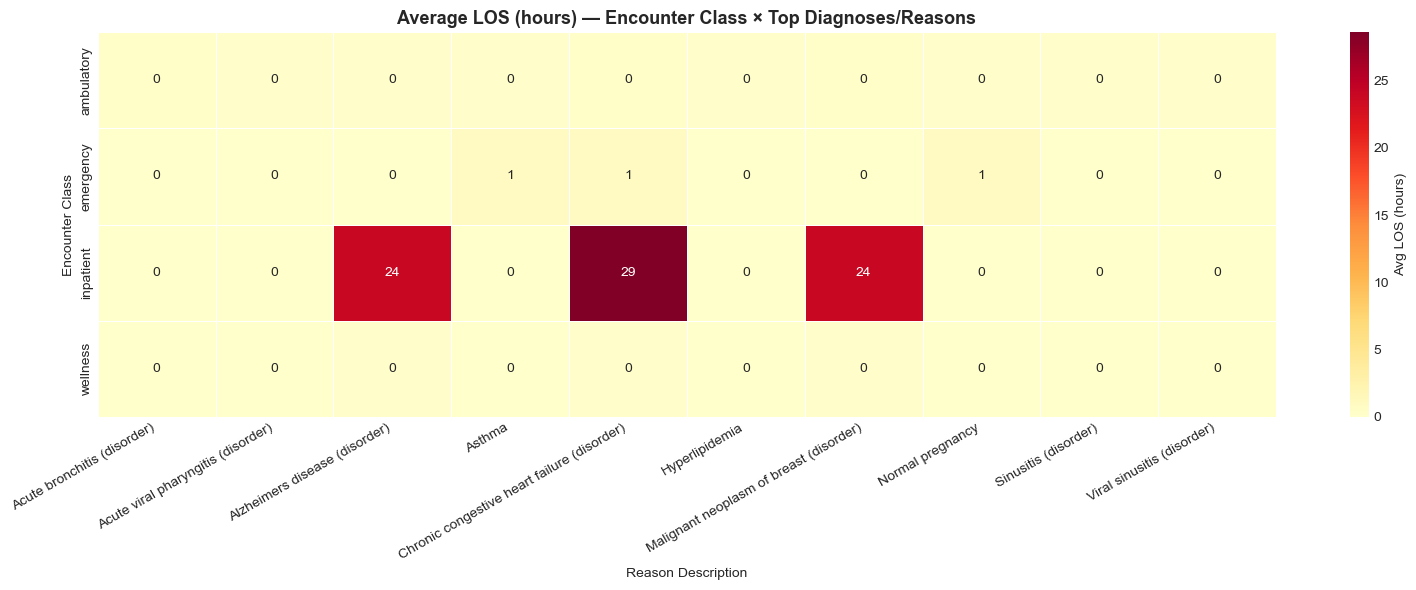

In [74]:
# ── 4.1  LOS Heatmap: Encounter Class × Reason ─────────────────────────────
top_reasons = df['reason_description'].value_counts().dropna().head(10).index
heatmap_data = (
    df[df['reason_description'].isin(top_reasons)]
    .groupby(['encounter_class', 'reason_description'])['los_hours']
    .mean()
    .unstack(fill_value=0)
    .round(1)
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg LOS (hours)'})
ax.set_title('Average LOS (hours) — Encounter Class × Top Diagnoses/Reasons', fontweight='bold', fontsize=13)
ax.set_xlabel('Reason Description')
ax.set_ylabel('Encounter Class')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'los_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [75]:
# ── 4.2  Cost vs LOS Correlation ────────────────────────────────────────────
from scipy import stats

corr_results = []
for cls in df['encounter_class'].unique():
    subset = df[df['encounter_class'] == cls][['los_hours', 'cost_capped']].dropna()
    if len(subset) > 10:
        r, p = stats.pearsonr(subset['los_hours'], subset['cost_capped'])
        rho, p2 = stats.spearmanr(subset['los_hours'], subset['cost_capped'])
        corr_results.append({'encounter_class': cls, 'pearson_r': round(r, 3), 'spearman_rho': round(rho, 3), 'n': len(subset)})

corr_df = pd.DataFrame(corr_results)
print('Cost vs LOS Correlations by Encounter Class:')
display(corr_df)

fig = px.scatter(
    df.sample(min(3000, len(df))),
    x='los_hours', y='cost_capped',
    color='encounter_class',
    opacity=0.5,
    title='Cost vs Length of Stay by Encounter Class',
    labels={'los_hours': 'LOS (hours)', 'cost_capped': 'Cost (USD)'},
    color_discrete_sequence=PALETTE,
    trendline='ols'
)
fig.update_layout(xaxis_range=[0, df['los_hours'].quantile(0.98)])
fig.show()

Cost vs LOS Correlations by Encounter Class:


,encounter_class,pearson_r,spearman_rho,n
0,emergency,0.029,0.174,2321
1,inpatient,0.028,0.173,1135
2,outpatient,-0.024,0.410,6297
3,ambulatory,-0.012,0.480,12534
4,wellness,NaN,NaN,1920
5,urgentcare,NaN,NaN,3665


High-utilizer patients (≥20 encounters): 365
Normal patients: 608


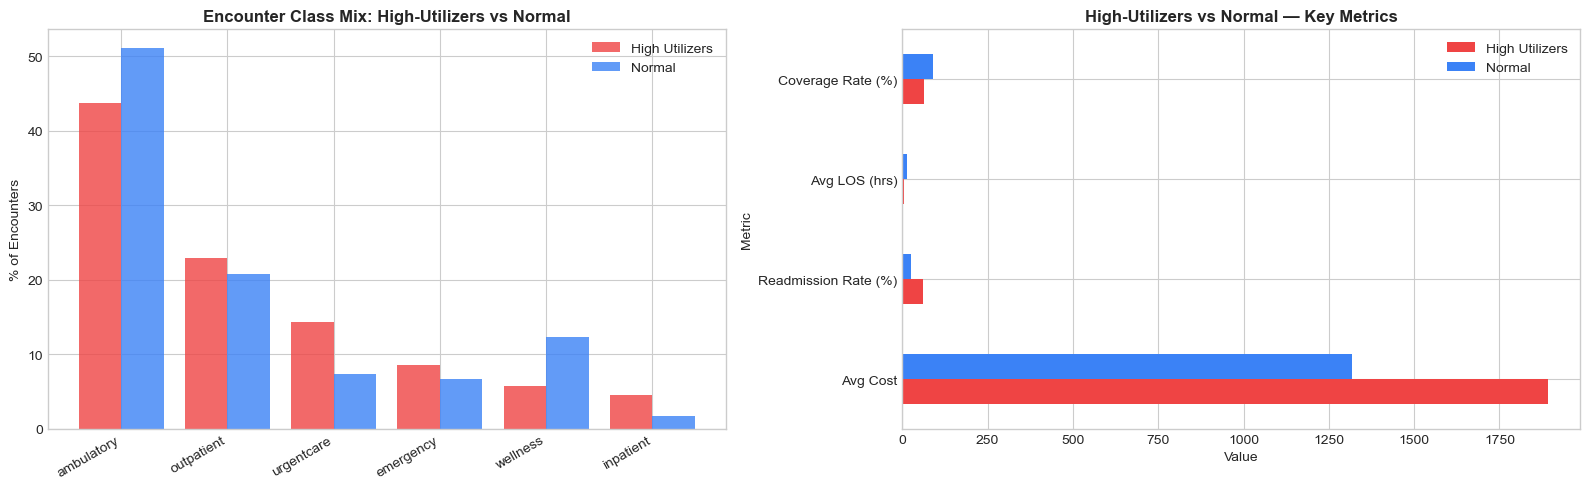

In [76]:
# ── 4.3  High-Utilizer Patient Profiles ─────────────────────────────────────
HIGH_UTIL_THRESHOLD = 20
high_util = df[df['total_encounters'] >= HIGH_UTIL_THRESHOLD]
normal = df[df['total_encounters'] < HIGH_UTIL_THRESHOLD]

print(f'High-utilizer patients (≥{HIGH_UTIL_THRESHOLD} encounters): {high_util["patient_id"].nunique():,}')
print(f'Normal patients: {normal["patient_id"].nunique():,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

util_class = high_util['encounter_class'].value_counts(normalize=True) * 100
normal_class = normal['encounter_class'].value_counts(normalize=True) * 100
x = range(len(util_class.index))
axes[0].bar([i - 0.2 for i in x], util_class.values, width=0.4, label='High Utilizers', color='#ef4444', alpha=0.8)
axes[0].bar([i + 0.2 for i in x], [normal_class.get(c, 0) for c in util_class.index], width=0.4, label='Normal', color='#3b82f6', alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(util_class.index, rotation=30, ha='right')
axes[0].set_title('Encounter Class Mix: High-Utilizers vs Normal', fontweight='bold')
axes[0].set_ylabel('% of Encounters')
axes[0].legend()

compare = pd.DataFrame({
    'Metric': ['Avg Cost', 'Readmission Rate (%)', 'Avg LOS (hrs)', 'Coverage Rate (%)'],
    'High Utilizers': [
        high_util['cost_capped'].mean(),
        high_util['readmission_30d'].mean() * 100,
        high_util['los_hours'].mean(),
        high_util['insurance_covered'].mean() * 100
    ],
    'Normal': [
        normal['cost_capped'].mean(),
        normal['readmission_30d'].mean() * 100,
        normal['los_hours'].mean(),
        normal['insurance_covered'].mean() * 100
    ]
})
compare = compare.set_index('Metric')
compare.plot(kind='barh', ax=axes[1], color=['#ef4444', '#3b82f6'])
axes[1].set_title('High-Utilizers vs Normal — Key Metrics', fontweight='bold')
axes[1].set_xlabel('Value')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'high_utilizers.png', dpi=150, bbox_inches='tight')
plt.show()

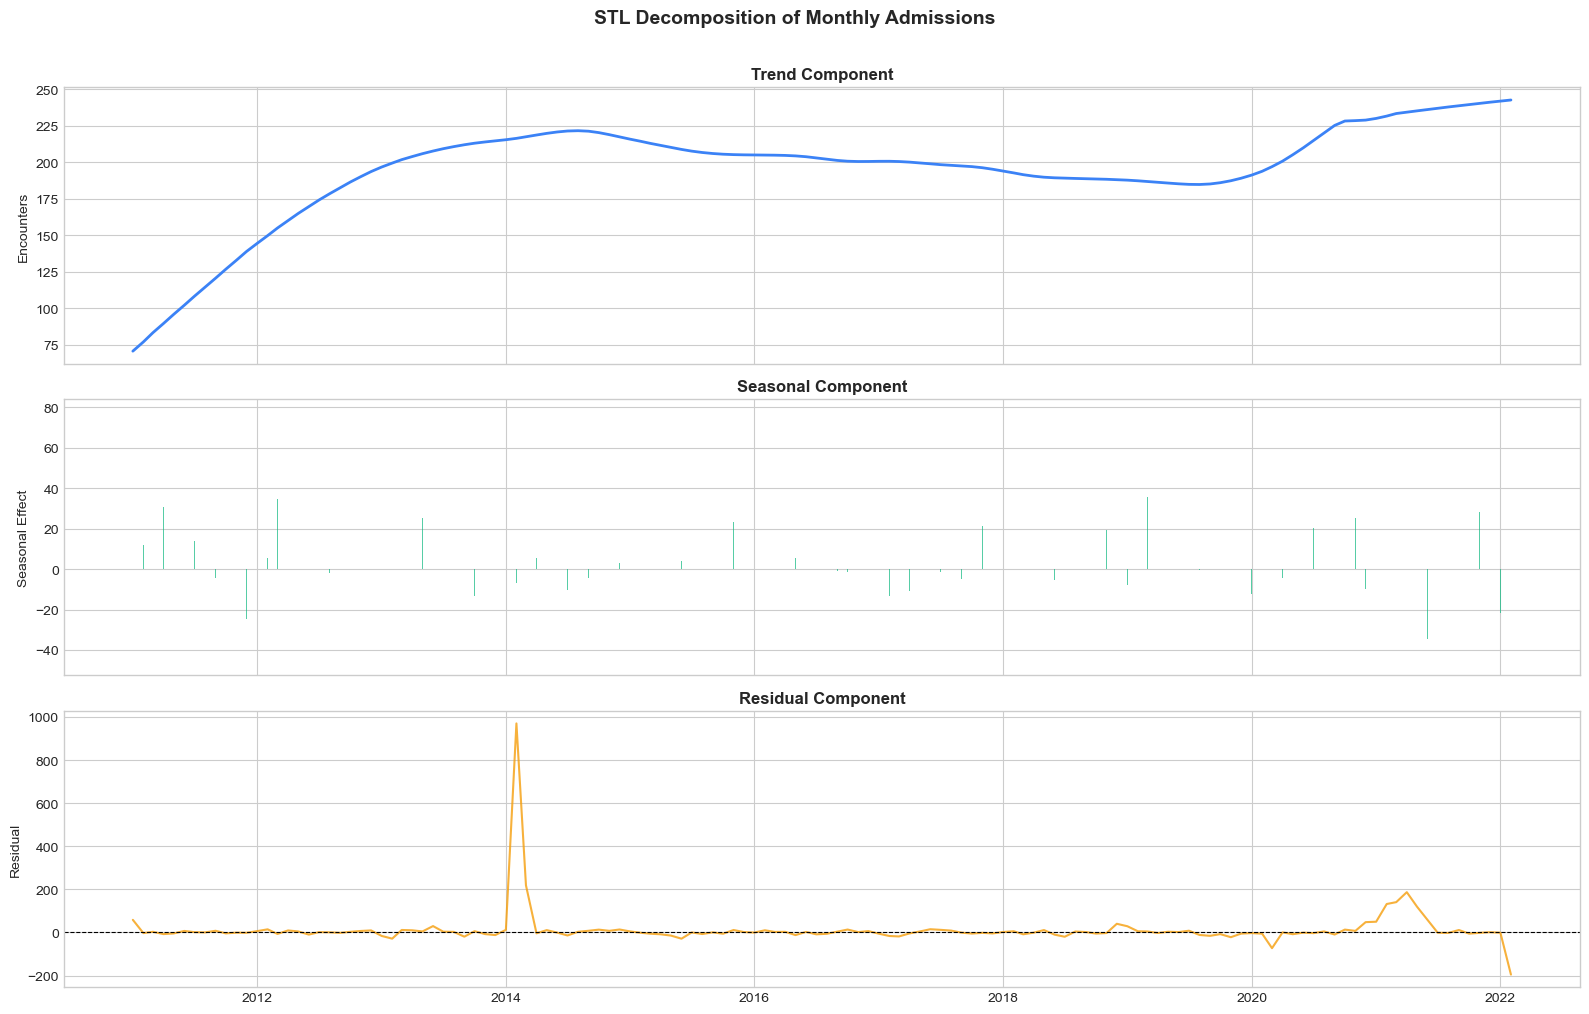

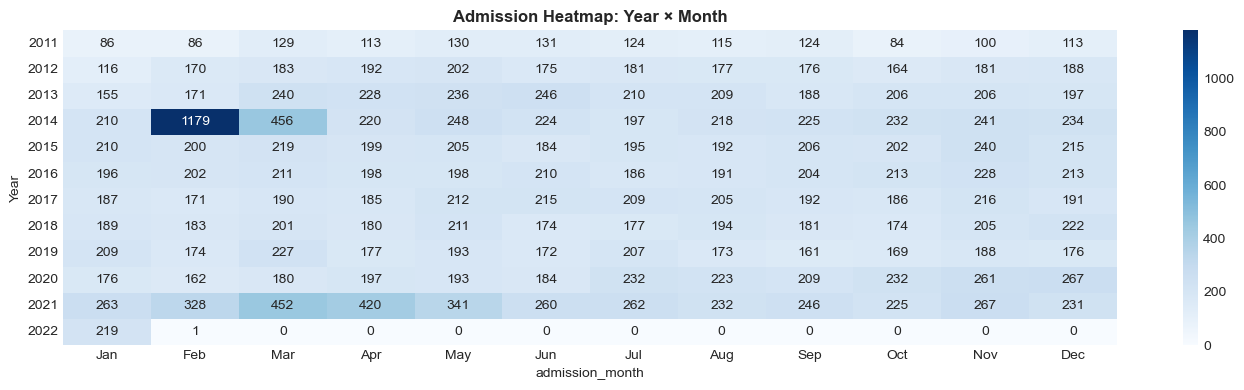

In [77]:
# ── 4.4  Seasonal Trends ─────────────────────────────────────────────────────
from statsmodels.tsa.seasonal import STL

monthly_ts = df.groupby('admission_yearmon').size().reset_index(name='count')
monthly_ts.index = pd.to_datetime(monthly_ts['admission_yearmon'] + '-01')
monthly_ts = monthly_ts.sort_index()

# STL decomposition (period=12 for monthly data)
if len(monthly_ts) >= 24:
    stl = STL(monthly_ts['count'], period=12, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    axes[0].plot(monthly_ts.index, result.trend, color='#3b82f6', lw=2)
    axes[0].set_title('Trend Component', fontweight='bold')
    axes[0].set_ylabel('Encounters')

    axes[1].bar(monthly_ts.index, result.seasonal, color='#10b981', alpha=0.7)
    axes[1].set_title('Seasonal Component', fontweight='bold')
    axes[1].set_ylabel('Seasonal Effect')

    axes[2].plot(monthly_ts.index, result.resid, color='#f59e0b', alpha=0.8)
    axes[2].axhline(0, color='black', lw=0.8, linestyle='--')
    axes[2].set_title('Residual Component', fontweight='bold')
    axes[2].set_ylabel('Residual')

    plt.suptitle('STL Decomposition of Monthly Admissions', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'seasonal_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough months for STL decomposition (need ≥24). Showing monthly bar chart.')
    monthly_ts['count'].plot(kind='bar', figsize=(16, 4), color='#3b82f6', alpha=0.8)
    plt.title('Monthly Admissions', fontweight='bold')
    plt.show()

# Seasonal heatmap: year × month
df['year_str'] = df['admission_year'].astype(str)
pivot = df.groupby(['year_str', 'admission_month']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Admission Heatmap: Year × Month', fontweight='bold')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
# ── 4.5  Top Expensive Procedures ───────────────────────────────────────────
proc_stats = df_proc.groupby(['procedure_code', 'procedure_name']).agg(
    avg_cost=('procedure_cost', 'mean'),
    median_cost=('procedure_cost', 'median'),
    total_cost=('procedure_cost', 'sum'),
    count=('procedure_cost', 'count')
).reset_index().sort_values('avg_cost', ascending=False).head(15)

fig = px.bar(
    proc_stats,
    x='avg_cost', y='procedure_name',
    orientation='h',
    color='count',
    color_continuous_scale='Blues',
    title='Top 15 Most Expensive Procedures (Avg Cost)',
    labels={'avg_cost': 'Average Cost (USD)', 'procedure_name': 'Procedure', 'count': 'Volume'},
    text=proc_stats['avg_cost'].apply(lambda x: f'${x:,.0f}')
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=500)
fig.show()

print('\nTop 15 Expensive Procedures:')
display(proc_stats[['procedure_name', 'avg_cost', 'median_cost', 'count', 'total_cost']].round(2))


Top 15 Expensive Procedures:


,procedure_name,avg_cost,median_cost,count,total_cost
72,Admit to ICU (procedure),206260.40,199610.0,5,1031302
44,Coronary artery bypass grafting,47085.89,43374.0,9,423773
88,Lumpectomy of breast (procedure),29353.00,29349.0,5,146765
70,Hemodialysis (procedure),29299.56,28314.0,27,791088
117,Insertion of biventricular implantable cardiov...,27201.00,25503.0,4,108804
33,Electrical cardioversion,25903.11,25066.0,1383,35824002
108,Partial resection of colon,25229.29,23031.0,7,176605
110,Fine needle aspiration biopsy of lung (procedure),23141.00,23141.0,1,23141
111,Percutaneous mechanical thrombectomy of portal...,20228.04,19073.0,57,1152998
99,Percutaneous coronary intervention,19728.00,17748.0,9,177552


---
## Section 5 — Predictive Models

In [79]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# ── 5.0  Prepare modeling dataset ──────────────────────────────────────────
model_df = df[[
    'encounter_class', 'payer_name', 'gender', 'age_group',
    'age_at_admission', 'los_hours', 'cost_per_day',
    'total_encounters', 'readmission_count',
    'insurance_covered', 'admission_quarter',
    'readmission_30d', 'high_cost_flag'
]].dropna()

# One-hot encode categoricals
model_df = pd.get_dummies(
    model_df,
    columns=['encounter_class', 'payer_name', 'gender', 'age_group'],
    drop_first=True
)
model_df['insurance_covered'] = model_df['insurance_covered'].astype(int)

READM_FEATURES = [c for c in model_df.columns if c not in ['readmission_30d', 'high_cost_flag']]
COST_FEATURES  = [c for c in READM_FEATURES if 'cost' not in c.lower()]

print(f'Model dataset: {len(model_df):,} rows | {len(READM_FEATURES)} readmission features | {len(COST_FEATURES)} cost features')
print(f'Readmission class balance: {model_df["readmission_30d"].value_counts().to_dict()}')
print(f'High-cost class balance:   {model_df["high_cost_flag"].value_counts().to_dict()}')

Model dataset: 27,872 rows | 26 readmission features | 25 cost features
Readmission class balance: {True: 15122, False: 12750}
High-cost class balance:   {False: 22284, True: 5588}


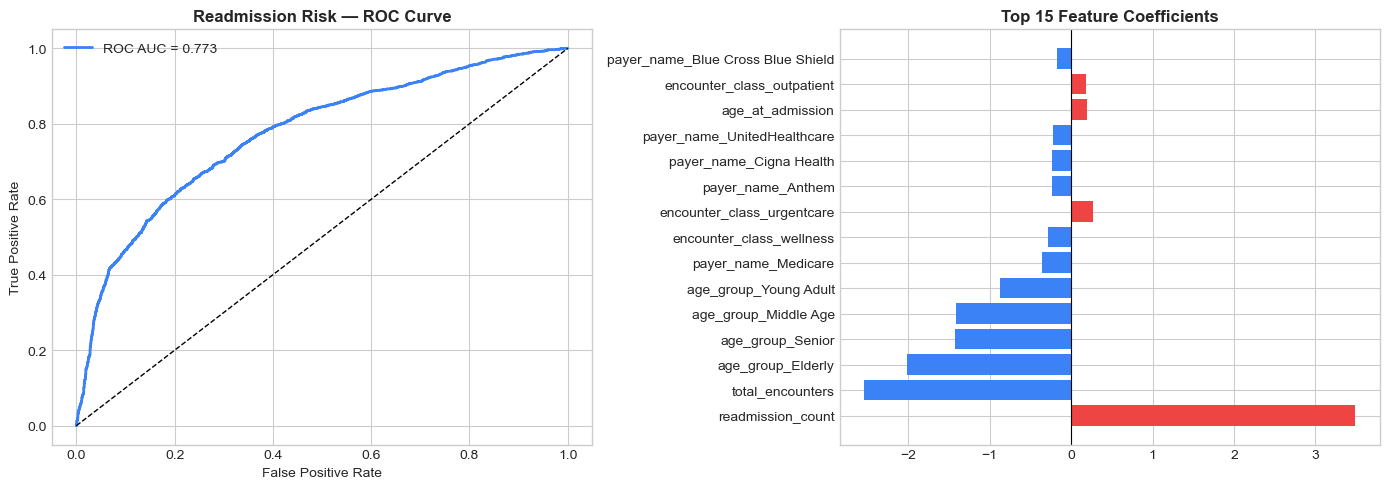

Best C: 1 | AUC: 0.7734
              precision    recall  f1-score   support

           0       0.65      0.76      0.70      2550
           1       0.76      0.66      0.71      3025

    accuracy                           0.70      5575
   macro avg       0.71      0.71      0.70      5575
weighted avg       0.71      0.70      0.70      5575



In [80]:
# ── 5.1  Readmission Risk — Logistic Regression ─────────────────────────────
X_r = model_df[READM_FEATURES]
y_r = model_df['readmission_30d'].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2, stratify=y_r, random_state=42)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_tr, y_tr)

scaler = StandardScaler()
X_res_s = scaler.fit_transform(X_res)
X_te_s  = scaler.transform(X_te)

lr_cv = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1
)
lr_cv.fit(X_res_s, y_res)
best_lr = lr_cv.best_estimator_

y_prob_r = best_lr.predict_proba(X_te_s)[:, 1]
auc_r = roc_auc_score(y_te, y_prob_r)
fpr, tpr, _ = roc_curve(y_te, y_prob_r)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color='#3b82f6', lw=2, label=f'ROC AUC = {auc_r:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_title('Readmission Risk — ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

coef_df = pd.DataFrame({'feature': READM_FEATURES, 'coef': best_lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(15)
colors = ['#ef4444' if c > 0 else '#3b82f6' for c in coef_df['coef']]
axes[1].barh(coef_df['feature'], coef_df['coef'], color=colors)
axes[1].set_title('Top 15 Feature Coefficients', fontweight='bold')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'readmission_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best C: {lr_cv.best_params_["C"]} | AUC: {auc_r:.4f}')
print(classification_report(y_te, best_lr.predict(X_te_s)))

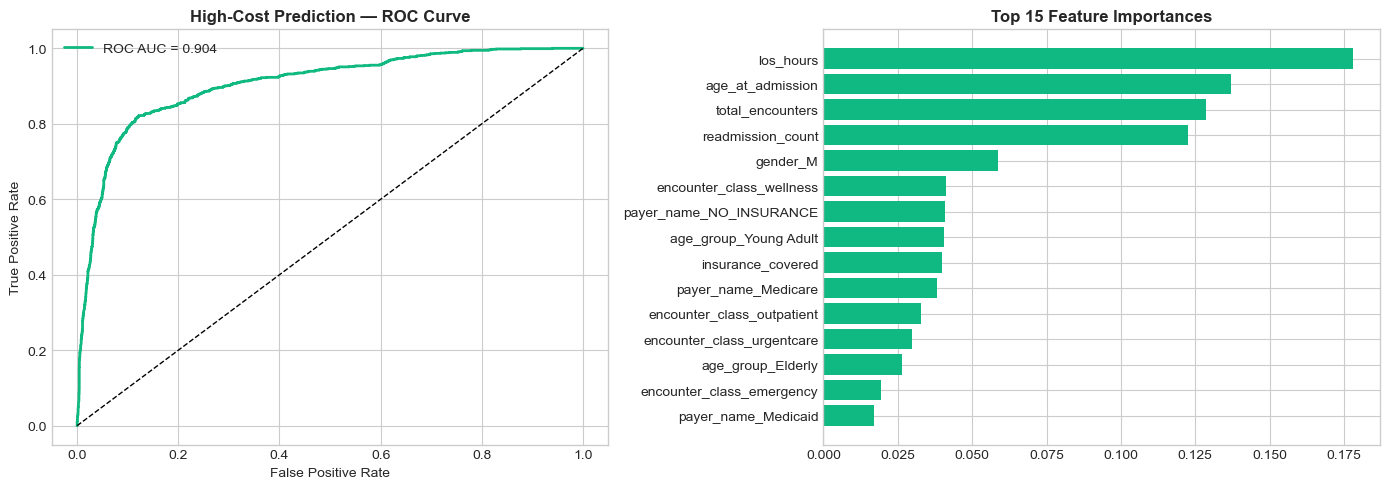

AUC: 0.9042
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      4457
           1       0.65      0.80      0.72      1118

    accuracy                           0.87      5575
   macro avg       0.80      0.85      0.82      5575
weighted avg       0.89      0.87      0.88      5575



In [81]:
# ── 5.2  High-Cost Prediction — Random Forest ───────────────────────────────
X_c = model_df[COST_FEATURES]
y_c = model_df['high_cost_flag'].astype(int)

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)

X_res2, y_res2 = sm.fit_resample(X_tr2, y_tr2)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_res2, y_res2)

y_prob_c = rf.predict_proba(X_te2)[:, 1]
auc_c = roc_auc_score(y_te2, y_prob_c)
fpr2, tpr2, _ = roc_curve(y_te2, y_prob_c)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr2, tpr2, color='#10b981', lw=2, label=f'ROC AUC = {auc_c:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_title('High-Cost Prediction — ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

fi_df = pd.DataFrame({'feature': COST_FEATURES, 'importance': rf.feature_importances_})
fi_df = fi_df.sort_values('importance', ascending=True).tail(15)
axes[1].barh(fi_df['feature'], fi_df['importance'], color='#10b981')
axes[1].set_title('Top 15 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cost_model.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC: {auc_c:.4f}')
print(classification_report(y_te2, rf.predict(X_te2)))

In [82]:
# ── 5.3  Model Cards ────────────────────────────────────────────────────────
print('=== MODEL CARD: Readmission Risk (Logistic Regression) ===')
print(f'Intended use:       Identify patients at risk of 30-day readmission for care coordination')
print(f'Training data:      {len(X_res):,} samples (SMOTE-balanced) from hospital_db encounters')
print(f'Test AUC:           {auc_r:.4f}')
print(f'Best C:             {lr_cv.best_params_["C"]}')
print(f'Limitations:        Binary classification; does not account for procedure complexity')
print(f'Fairness note:      Race/ethnicity not used as features; monitor for proxy bias via ZIP/payer')
print()
print('=== MODEL CARD: High-Cost Prediction (Random Forest) ===')
print(f'Intended use:       Predict high-cost encounters pre-billing for resource allocation')
print(f'Training data:      {len(X_res2):,} samples (SMOTE-balanced)')
print(f'Test AUC:           {auc_c:.4f}')
print(f'Limitations:        Top 20% threshold is department-relative; absolute cost varies widely')
print(f'Fairness note:      Insurance type included — review disparate impact on uninsured patients')

=== MODEL CARD: Readmission Risk (Logistic Regression) ===
Intended use:       Identify patients at risk of 30-day readmission for care coordination
Training data:      24,194 samples (SMOTE-balanced) from hospital_db encounters
Test AUC:           0.7734
Best C:             1
Limitations:        Binary classification; does not account for procedure complexity
Fairness note:      Race/ethnicity not used as features; monitor for proxy bias via ZIP/payer

=== MODEL CARD: High-Cost Prediction (Random Forest) ===
Intended use:       Predict high-cost encounters pre-billing for resource allocation
Training data:      35,654 samples (SMOTE-balanced)
Test AUC:           0.9042
Limitations:        Top 20% threshold is department-relative; absolute cost varies widely
Fairness note:      Insurance type included — review disparate impact on uninsured patients


---
## Section 6 — JSON Export for API

In [83]:
# ── 6.1  admissions_trend.json ──────────────────────────────────────────────
def safe_val(v):
    """Convert numpy types to Python native for JSON serialization."""
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating,)): return round(float(v), 4)
    if isinstance(v, (np.bool_,)): return bool(v)
    if pd.isna(v): return None
    return v

def df_to_records(frame):
    return [{k: safe_val(v) for k, v in row.items()} for row in frame.to_dict(orient='records')]

# Daily
daily = df.groupby(df['admission_date'].dt.date).agg(
    admissions=('encounter_id','count'),
    readmissions=('readmission_30d','sum')
).reset_index()
daily['readmission_rate'] = (daily['readmissions'] / daily['admissions']).round(4)
daily['date'] = daily['admission_date'].astype(str)

# Weekly
df['admission_yearweek'] = df['admission_date'].dt.strftime('%G-W%V')
weekly = df.groupby('admission_yearweek').agg(
    admissions=('encounter_id','count'),
    readmissions=('readmission_30d','sum')
).reset_index()
weekly['readmission_rate'] = (weekly['readmissions'] / weekly['admissions']).round(4)
weekly = weekly.rename(columns={'admission_yearweek': 'week'})

# Monthly
monthly_out = df.groupby('admission_yearmon').agg(
    admissions=('encounter_id','count'),
    readmissions=('readmission_30d','sum')
).reset_index()
monthly_out['readmission_rate'] = (monthly_out['readmissions'] / monthly_out['admissions']).round(4)
monthly_out = monthly_out.rename(columns={'admission_yearmon': 'month'})

admissions_trend = {
    'daily':   df_to_records(daily[['date','admissions','readmissions','readmission_rate']]),
    'weekly':  df_to_records(weekly[['week','admissions','readmissions','readmission_rate']]),
    'monthly': df_to_records(monthly_out[['month','admissions','readmissions','readmission_rate']]),
    'meta': {
        'total_admissions': safe_val(len(df)),
        'date_range': {'start': str(df['admission_date'].min().date()), 'end': str(df['admission_date'].max().date())}
    }
}

(PROCESSED_DIR / 'admissions_trend.json').write_text(json.dumps(admissions_trend, default=str))
print('admissions_trend.json written')

admissions_trend.json written


In [84]:
# ── 6.2  los_metrics.json ───────────────────────────────────────────────────
def los_summary(series):
    return {
        'mean':   safe_val(series.mean()),
        'median': safe_val(series.median()),
        'p25':    safe_val(series.quantile(0.25)),
        'p75':    safe_val(series.quantile(0.75)),
        'p95':    safe_val(series.quantile(0.95)),
        'std':    safe_val(series.std())
    }

by_class = []
for cls, grp in df.groupby('encounter_class'):
    s = los_summary(grp['los_hours'])
    s['label'] = cls
    s['count'] = safe_val(len(grp))
    by_class.append(s)

by_reason = []
for reason, grp in df[df['reason_description'].notna()].groupby('reason_description'):
    if len(grp) >= 20:
        s = los_summary(grp['los_hours'])
        s['label'] = reason
        s['count'] = safe_val(len(grp))
        by_reason.append(s)
by_reason = sorted(by_reason, key=lambda x: x['count'], reverse=True)[:20]

# Distribution: bin LOS hours
bins = [0, 1, 4, 8, 24, 48, 72, 168, 336, 720]
labels_b = ['<1h', '1-4h', '4-8h', '8-24h', '1-2d', '2-3d', '3-7d', '7-14d', '>14d']
df['los_bucket'] = pd.cut(df['los_hours'], bins=bins, labels=labels_b, right=True)
dist = df['los_bucket'].value_counts().sort_index().reset_index()
dist.columns = ['los_range', 'count']

los_metrics = {
    'overall_hours': los_summary(df['los_hours']),
    'inpatient_days': los_summary(df[df['is_inpatient']]['los_days']),
    'by_encounter_class': by_class,
    'by_reason': by_reason,
    'distribution': df_to_records(dist)
}

(PROCESSED_DIR / 'los_metrics.json').write_text(json.dumps(los_metrics, default=str))
print('los_metrics.json written')

los_metrics.json written


In [85]:
# ── 6.3  cost_analysis.json ─────────────────────────────────────────────────
def cost_summary(series):
    return {
        'mean':   safe_val(series.mean()),
        'median': safe_val(series.median()),
        'p95':    safe_val(series.quantile(0.95)),
        'total':  safe_val(series.sum())
    }

by_class_cost = []
for cls, grp in df.groupby('encounter_class'):
    s = cost_summary(grp['cost_capped'])
    s['label'] = cls; s['count'] = safe_val(len(grp))
    by_class_cost.append(s)

by_payer_cost = []
for payer, grp in df.groupby('payer_name'):
    s = cost_summary(grp['cost_capped'])
    s['label'] = payer; s['count'] = safe_val(len(grp))
    by_payer_cost.append(s)

# Cost distribution buckets
cost_bins = [0, 100, 500, 1000, 5000, 10000, 25000, 50000, 100000, float('inf')]
cost_labels = ['<$100','$100-500','$500-1k','$1k-5k','$5k-10k','$10k-25k','$25k-50k','$50k-100k','>$100k']
df['cost_bucket'] = pd.cut(df['cost_capped'], bins=cost_bins, labels=cost_labels, right=True)
cost_dist = df['cost_bucket'].value_counts().sort_index().reset_index()
cost_dist.columns = ['range', 'count']
cost_dist['pct'] = (cost_dist['count'] / len(df) * 100).round(2)

# Top procedures
top_proc = proc_stats.rename(columns={'procedure_name': 'name', 'procedure_code': 'code'}).head(15)
top_proc_records = [{k: safe_val(v) for k, v in r.items()} for r in top_proc.to_dict(orient='records')]

cost_analysis = {
    'overall': cost_summary(df['cost_capped']),
    'by_encounter_class': by_class_cost,
    'by_payer': by_payer_cost,
    'top_procedures': top_proc_records,
    'distribution_buckets': df_to_records(cost_dist)
}

(PROCESSED_DIR / 'cost_analysis.json').write_text(json.dumps(cost_analysis, default=str))
print('cost_analysis.json written')

cost_analysis.json written


In [86]:
# ── 6.4  insurance_coverage.json ────────────────────────────────────────────
overall_cov = {
    'covered':      safe_val(df['insurance_covered'].sum()),
    'uncovered':    safe_val((~df['insurance_covered']).sum()),
    'coverage_pct': safe_val(df['insurance_covered'].mean() * 100)
}

by_payer_cov = []
for payer, grp in df.groupby('payer_name'):
    by_payer_cov.append({
        'label': payer,
        'count': safe_val(len(grp)),
        'covered': safe_val(grp['insurance_covered'].sum()),
        'coverage_pct': safe_val(grp['insurance_covered'].mean() * 100),
        'avg_cost': safe_val(grp['cost_capped'].mean()),
        'avg_out_of_pocket': safe_val(grp['out_of_pocket'].mean()),
        'avg_coverage_ratio': safe_val(grp['coverage_ratio'].mean())
    })

by_class_cov = []
for cls, grp in df.groupby('encounter_class'):
    by_class_cov.append({
        'label': cls,
        'count': safe_val(len(grp)),
        'covered': safe_val(grp['insurance_covered'].sum()),
        'coverage_pct': safe_val(grp['insurance_covered'].mean() * 100),
        'avg_out_of_pocket': safe_val(grp['out_of_pocket'].mean())
    })

insurance_coverage = {
    'overall': overall_cov,
    'by_payer': by_payer_cov,
    'by_encounter_class': by_class_cov
}

(PROCESSED_DIR / 'insurance_coverage.json').write_text(json.dumps(insurance_coverage, default=str))
print('insurance_coverage.json written')

insurance_coverage.json written


In [87]:
# ── 6.5  kpi_summary.json ───────────────────────────────────────────────────
kpi_summary = {
    'total_patients':         safe_val(df['patient_id'].nunique()),
    'total_encounters':       safe_val(len(df)),
    'total_procedures':       safe_val(len(df_proc)),
    'avg_los_hours':          safe_val(df['los_hours'].mean()),
    'median_los_hours':       safe_val(df['los_hours'].median()),
    'avg_los_days_inpatient': safe_val(df[df['is_inpatient']]['los_days'].mean()),
    'avg_cost':               safe_val(df['cost_capped'].mean()),
    'median_cost':            safe_val(df['cost_capped'].median()),
    'total_revenue':          safe_val(df['total_cost'].sum()),
    'total_payer_coverage':   safe_val(df['payer_coverage'].sum()),
    'readmission_rate_30d':   safe_val(df['readmission_30d'].mean()),
    'insurance_coverage_rate':safe_val(df['insurance_covered'].mean()),
    'avg_out_of_pocket':      safe_val(df['out_of_pocket'].mean()),
    'date_range': {
        'start': str(df['admission_date'].min().date()),
        'end':   str(df['admission_date'].max().date())
    }
}

(PROCESSED_DIR / 'kpi_summary.json').write_text(json.dumps(kpi_summary, default=str))
print('kpi_summary.json written')
print(json.dumps(kpi_summary, indent=2))

kpi_summary.json written
{
  "total_patients": 973,
  "total_encounters": 27872,
  "total_procedures": 47701,
  "avg_los_hours": 7.2707,
  "median_los_hours": 0.25,
  "avg_los_days_inpatient": 1.5351,
  "avg_cost": 1796.1482,
  "median_cost": 278.58,
  "total_revenue": 101471583.76,
  "total_payer_coverage": 31063671.38,
  "readmission_rate_30d": 0.5426,
  "insurance_coverage_rate": 0.684,
  "avg_out_of_pocket": 2526.1163,
  "date_range": {
    "start": "2011-01-02",
    "end": "2022-02-05"
  }
}


In [88]:
# ── 6.6  risk_patients.json ─────────────────────────────────────────────────
# Compute risk score per patient: weighted combination of normalized signals
patient_risk = df.groupby('patient_id').agg(
    age=('age_at_admission', 'mean'),
    age_group=('age_group', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
    encounter_class=('encounter_class', lambda x: x.mode()[0]),
    total_encounters=('total_encounters', 'first'),
    readmission_count=('readmission_count', 'first'),
    avg_cost=('cost_capped', 'mean'),
    insurance_covered=('insurance_covered', 'any'),
    reason=('reason_description', lambda x: x.dropna().mode()[0] if x.dropna().any() else 'Unknown')
).reset_index()

# Normalize components
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

patient_risk['risk_score'] = (
    0.35 * norm(patient_risk['readmission_count']) +
    0.30 * norm(patient_risk['total_encounters']) +
    0.20 * norm(patient_risk['age']) +
    0.15 * (~patient_risk['insurance_covered']).astype(float)
).round(4)

top_risk = patient_risk.nlargest(200, 'risk_score').copy()
# Anonymize patient_id (keep last 8 chars)
top_risk['patient_id'] = top_risk['patient_id'].str[-8:].apply(lambda x: f'PT-{x.upper()}')
top_risk['age_group'] = top_risk['age_group'].astype(str)
top_risk['insurance_covered'] = top_risk['insurance_covered'].astype(bool)

risk_records = [{k: safe_val(v) for k, v in r.items()} for r in top_risk.to_dict(orient='records')]

(PROCESSED_DIR / 'risk_patients.json').write_text(json.dumps(risk_records, default=str))
print(f'risk_patients.json written — {len(risk_records)} high-risk patients')
print('\nAll 6 JSON files exported successfully:')
for f in PROCESSED_DIR.glob('*.json'):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:35s} {size_kb:.1f} KB')

risk_patients.json written — 200 high-risk patients

All 6 JSON files exported successfully:
  admissions_trend.json               402.8 KB
  cost_analysis.json                  4.7 KB
  insurance_coverage.json             2.4 KB
  kpi_summary.json                    0.4 KB
  los_metrics.json                    4.3 KB
  risk_patients.json                  52.6 KB
